## NVDA Time Series – Main Notebook

This notebook replaces the previous `main.py` script as the primary interactive entry point for the NVDA projects.

Use it to:
- Download and load the NVDA dataset.
- Run preprocessing and basic data description.
- Inspect the DataFrame with commands like `df.head()`.
- Later: perform transformations to returns and add visualizations (after we verify the time-series structure).


In [91]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Data import and cleaning

In [17]:
df = yf.download(
    tickers="NVDA",
    start="2021-01-01",
    end="2026-03-05",
    auto_adjust=True,
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index = pd.to_datetime(df.index)
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(1297, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,13.076014,13.613473,12.925445,13.066790,560640000
2021-01-05,13.366434,13.405073,13.049592,13.062306,322760000
2021-01-06,12.578445,13.207143,12.550027,13.184707,580424000
2021-01-07,13.305860,13.339514,12.849668,12.930436,461480000
2021-01-08,13.238801,13.382639,13.004722,13.324306,292528000


In [18]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df.index.min(), "→", df.index.max())
df.describe()

Shape: (1297, 5)

Dtypes:
 Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Date range: 2021-01-04 00:00:00 → 2026-03-04 00:00:00


Price,Close,High,Low,Open,Volume
count,1297.000000,1297.000000,1297.000000,1297.000000,1.297000e+03
mean,71.034968,72.237545,69.732909,71.058949,3.879523e+08
std,60.321858,61.227197,59.399358,60.416650,1.846455e+08
min,11.212296,11.719631,10.798838,10.956631,6.552850e+07
25%,19.617065,19.983222,19.206003,19.640009,2.313979e+08
50%,42.963417,43.580941,42.101086,42.718129,3.713890e+08
75%,123.990822,126.439034,120.971677,123.739454,5.011480e+08
max,207.017273,212.166717,205.537422,208.057150,1.543911e+09


In [19]:
# Drop duplicated index rows if any
df = df[~df.index.duplicated(keep="first")]

# Drop rows where Close is missing (the target column)
df = df.dropna(subset=["Close"])

# Forward-fill any remaining gaps (e.g. sparse Volume on holidays)
df = df.ffill()

print("Shape after cleaning:", df.shape)
print("Missing values:\n", df.isnull().sum())

Shape after cleaning: (1297, 5)
Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


# Feature Engineering

In [20]:
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

In [21]:
df["Lag_1"] = df["Log_Return"].shift(1)
df["Lag_2"] = df["Log_Return"].shift(2)
df["Lag_5"] = df["Log_Return"].shift(5)

In [22]:
df["Volatility_10"] = df["Log_Return"].rolling(window=10).std()
df["Volatility_20"] = df["Log_Return"].rolling(window=20).std()

In [23]:
rolling_mean = df["Close"].rolling(window=20).mean()
rolling_std  = df["Close"].rolling(window=20).std()
bb_upper     = rolling_mean + (2 * rolling_std)
bb_lower     = rolling_mean - (2 * rolling_std)
bb_width     = bb_upper - bb_lower

df["BB_Pct"] = (df["Close"] - bb_lower) / bb_width

In [24]:
df["Volume_Change"] = df["Volume"].pct_change()

In [25]:
sp500 = yf.download("^GSPC", start="2021-01-01", end="2026-03-05", auto_adjust=True)["Close"].squeeze()
vix   = yf.download("^VIX",  start="2021-01-01", end="2026-03-05", auto_adjust=True)["Close"].squeeze()

df["SP500_Return"] = np.log(sp500 / sp500.shift(1))
df["VIX"] = vix

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
df["Target"] = df["Log_Return"].shift(-1)

In [27]:
df = df.dropna()

print("Final shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Final shape: (1276, 16)
Missing values:
 Price
Close            0
High             0
Low              0
Open             0
Volume           0
Log_Return       0
Lag_1            0
Lag_2            0
Lag_5            0
Volatility_10    0
Volatility_20    0
BB_Pct           0
Volume_Change    0
SP500_Return     0
VIX              0
Target           0
dtype: int64


# EDA

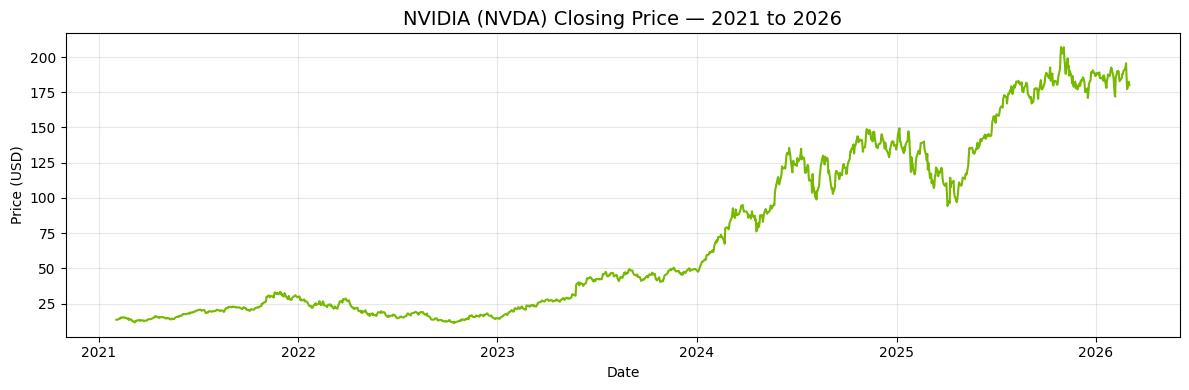

In [47]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["Close"], color="#76b900", linewidth=1.5)  

ax.set_title("NVIDIA (NVDA) Closing Price — 2021 to 2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

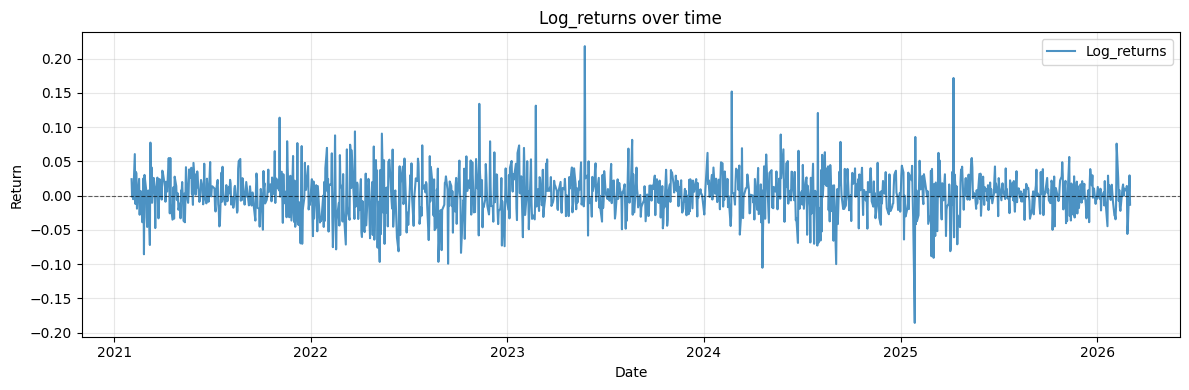

In [31]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df["Log_Return"], label="Log_returns", alpha=0.8)

plt.title("Log_returns over time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

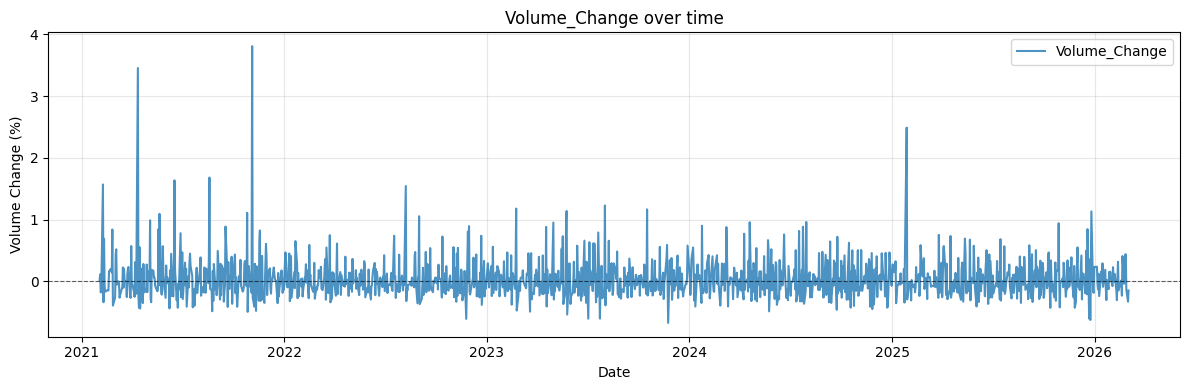

In [68]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df["Volume_Change"], label="Volume_Change", alpha=0.8)

plt.title("Volume_Change over time")
plt.xlabel("Date")
plt.ylabel("Volume Change (%)")
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
df["Volume"].sort_values(ascending=False).head()

Date
2023-05-25    1543911000
2022-09-01    1178865000
2023-08-24    1156044000
2021-11-04    1153631000
2024-03-08    1142269000
Name: Volume, dtype: int64

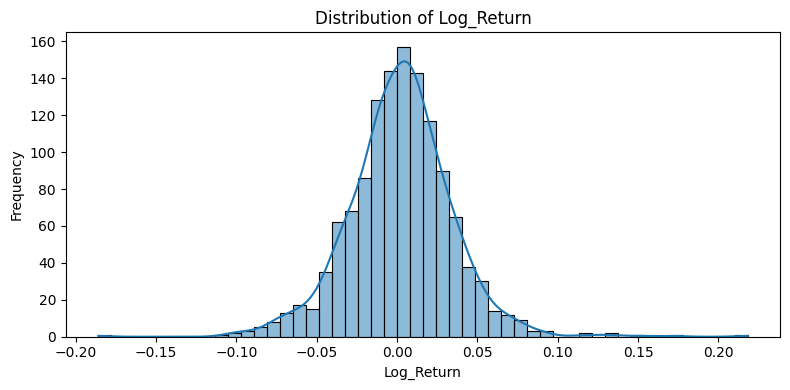

In [34]:
plt.figure(figsize=(8, 4))
sns.histplot(data, bins=50, kde=True)

plt.xlabel("Log_Return")
plt.ylabel("Frequency")
plt.title(f"Distribution of {"Log_Return"}")
plt.tight_layout()
plt.show()

C:\Users\ass\AppData\Local\Temp\ipykernel_8108\3410574982.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Year", y="Log_Return", ax=ax, palette="Blues")


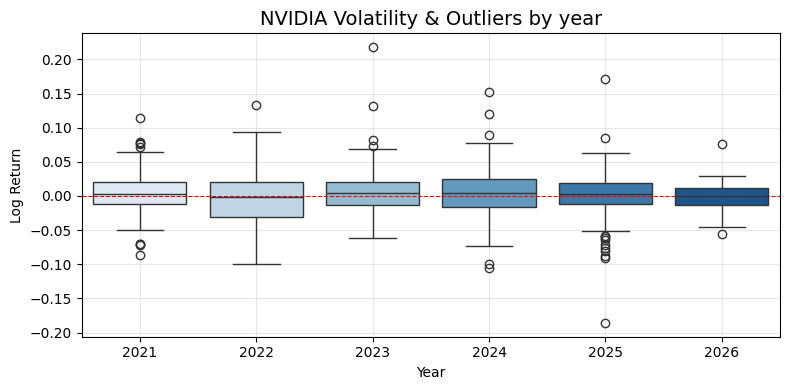

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

df_box = df[["Log_Return"]].copy()
df_box["Year"] = df.index.year

sns.boxplot(data=df_box, x="Year", y="Log_Return", ax=ax, palette="Blues")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")

ax.set_title("NVIDIA Volatility & Outliers by year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Log Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

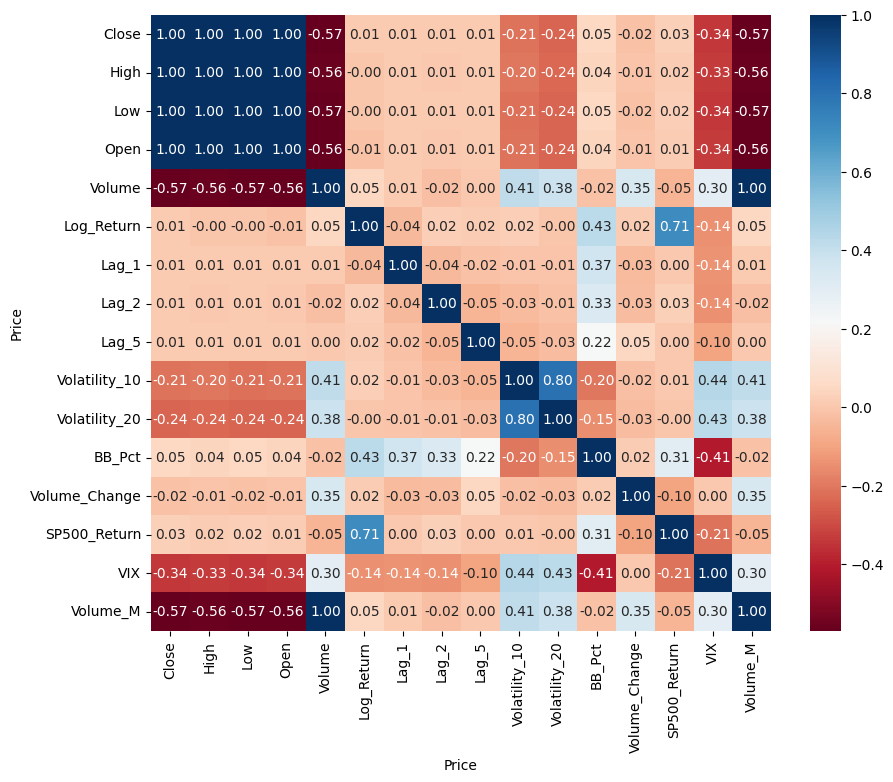

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.drop(columns=["Target"]).corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu")
plt.show()

# ADF Test Staionarity

In [80]:
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval, lags, nobs, crit, _ = result

    print(f"{name}")
    print(f"ADF Statistic: {stat:.4f}")
    print(f"p-value: {pval:.4f}")
    print(f"Used lags: {lags}")
    
    for k, v in crit.items():
        print(f"Critical Value ({k}): {v:.4f}")

    if pval < 0.05:
        print("Stationary (reject H0)")
    else:
        print("Non-stationary (fail to reject H0)")
    
    print()

In [84]:
run_adf(df["Log_Return"], "NVIDIA Log Returns")

run_adf(df["VIX"], "VIX (level series)")

run_adf(df["SP500_Return"], "S&P 500 Log Returns")

NVIDIA Log Returns
ADF Statistic: -21.6025
p-value: 0.0000
Used lags: 2
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)

VIX (level series)
ADF Statistic: -4.9555
p-value: 0.0000
Used lags: 4
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)

S&P 500 Log Returns
ADF Statistic: -22.2530
p-value: 0.0000
Used lags: 2
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)



In [87]:
split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

features = ["Lag_1", "Lag_2", "Lag_5", "Volatility_10", "Volatility_20", "BB_Pct", "Volume_Change", "SP500_Return", "VIX"]

X_train = train[features]
y_train = train["Target"]

X_test  = test[features]
y_test  = test["Target"]

print(f"Training set : {X_train.shape[0]} observations  ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Testing set  : {X_test.shape[0]}  observations  ({test.index[0].date()}  to {test.index[-1].date()})")

Training set : 1020 observations  (2021-02-02 to 2025-02-24)
Testing set  : 256  observations  (2025-02-25  to 2026-03-03)


# Preprocessing